In [ ]:

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os
from PIL import Image


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Kullanılan Cihaz: {device}")


torch.manual_seed(42)
if device.type == 'cuda':
    torch.cuda.manual_seed(42)

Kullanılan Cihaz: cuda


In [ ]:

import zipfile

zip_path = 'fer2013_data.zip'
extract_path = './fer2013_dataset' 

if not os.path.exists(extract_path):
    print("Zip dosyası çıkartılıyor...")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print("Çıkarma işlemi tamamlandı!")
else:
    print("Klasör zaten mevcut, atlanıyor.")


train_dir = os.path.join(extract_path, 'train')
test_dir = os.path.join(extract_path, 'test')


if os.path.exists(train_dir):
    print(f"Bulunan sınıflar: {os.listdir(train_dir)}")
else:
    print("UYARI: 'train' klasörü bulunamadı! Zip içeriğini kontrol edin.")

Zip dosyası çıkartılıyor...
Çıkarma işlemi tamamlandı!
Bulunan sınıflar: ['sad', 'fear', 'surprise', 'happy', 'neutral', 'angry', 'disgust']


In [ ]:



mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]

data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((224, 224)),       
        transforms.Grayscale(num_output_channels=3), 
        transforms.RandomHorizontalFlip(),   
        transforms.ToTensor(),
        transforms.Normalize(mean, std)
    ]),
    'test': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.Grayscale(num_output_channels=3),
        transforms.ToTensor(),
        transforms.Normalize(mean, std)
    ]),
}


image_datasets = {
    'train': datasets.ImageFolder(train_dir, data_transforms['train']),
    'test': datasets.ImageFolder(test_dir, data_transforms['test'])
}

dataloaders = {
    'train': DataLoader(image_datasets['train'], batch_size=32, shuffle=True, num_workers=2),
    'test': DataLoader(image_datasets['test'], batch_size=32, shuffle=False, num_workers=2)
}

dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'test']}
class_names = image_datasets['train'].classes

print(f"Sınıflar: {class_names}")
print(f"Eğitim Verisi: {dataset_sizes['train']}, Test Verisi: {dataset_sizes['test']}")

Sınıflar: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
Eğitim Verisi: 28709, Test Verisi: 7178


In [ ]:


def get_wide_resnet_model():
    print("Wide ResNet-50-2 (ImageNet Weights) yükleniyor...")
    
    model = models.wide_resnet50_2(weights=models.Wide_ResNet50_2_Weights.DEFAULT)

    
    num_ftrs = model.fc.in_features
    model.fc = nn.Linear(num_ftrs, len(class_names))

    return model.to(device)

model = get_wide_resnet_model()


criterion = nn.CrossEntropyLoss()


optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-4)


scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=4, gamma=0.1)

Wide ResNet-50-2 (ImageNet Weights) yükleniyor...
Downloading: "https://download.pytorch.org/models/wide_resnet50_2-9ba9bcbe.pth" to /root/.cache/torch/hub/checkpoints/wide_resnet50_2-9ba9bcbe.pth


100%|██████████| 263M/263M [00:01<00:00, 207MB/s]


In [ ]:

import time
import copy

def train_model(model, criterion, optimizer, scheduler, num_epochs=10):
    since = time.time()

    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0

    
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    for epoch in range(num_epochs):
        print(f'Epoch {epoch+1}/{num_epochs}')
        print('-' * 10)

        for phase in ['train', 'test']:
            if phase == 'train':
                model.train()
            else:
                model.eval()

            running_loss = 0.0
            running_corrects = 0

            
            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)

                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            if phase == 'train':
                scheduler.step()

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.double() / dataset_sizes[phase]

            print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

            
            if phase == 'train':
                history['train_loss'].append(epoch_loss)
                history['train_acc'].append(epoch_acc.item())
            else:
                history['val_loss'].append(epoch_loss)
                history['val_acc'].append(epoch_acc.item())

                
                if epoch_acc > best_acc:
                    best_acc = epoch_acc
                    best_model_wts = copy.deepcopy(model.state_dict())
                    torch.save(model.state_dict(), 'wide_resnet50_best.pth') # Checkpoint

    time_elapsed = time.time() - since
    print(f'\nEğitim Tamamlandı: {time_elapsed // 60:.0f}dk {time_elapsed % 60:.0f}sn')
    print(f'En Yüksek Test Doğruluğu (Best Val Acc): {best_acc:4f}')

    
    model.load_state_dict(best_model_wts)
    return model, history

In [ ]:
# BLOK 6: Eğitimi Çalıştır

model, history = train_model(model, criterion, optimizer, scheduler, num_epochs=10)

Epoch 1/10
----------
train Loss: 1.1649 Acc: 0.5581
test Loss: 0.9786 Acc: 0.6343
Epoch 2/10
----------
train Loss: 0.8945 Acc: 0.6677
test Loss: 0.9266 Acc: 0.6619
Epoch 3/10
----------
train Loss: 0.7705 Acc: 0.7140
test Loss: 0.9072 Acc: 0.6695
Epoch 4/10
----------
train Loss: 0.6516 Acc: 0.7613
test Loss: 0.9148 Acc: 0.6773
Epoch 5/10
----------
train Loss: 0.4150 Acc: 0.8567
test Loss: 0.9274 Acc: 0.6992
Epoch 6/10
----------
train Loss: 0.3189 Acc: 0.8893
test Loss: 0.9613 Acc: 0.7008
Epoch 7/10
----------
train Loss: 0.2563 Acc: 0.9127
test Loss: 1.0162 Acc: 0.7008
Epoch 8/10
----------
train Loss: 0.2094 Acc: 0.9287
test Loss: 1.0723 Acc: 0.7012
Epoch 9/10
----------
train Loss: 0.1666 Acc: 0.9478
test Loss: 1.0855 Acc: 0.7055
Epoch 10/10
----------
train Loss: 0.1569 Acc: 0.9521
test Loss: 1.0988 Acc: 0.7047

Eğitim Tamamlandı: 95dk 12sn
En Yüksek Test Doğruluğu (Best Val Acc): 0.705489


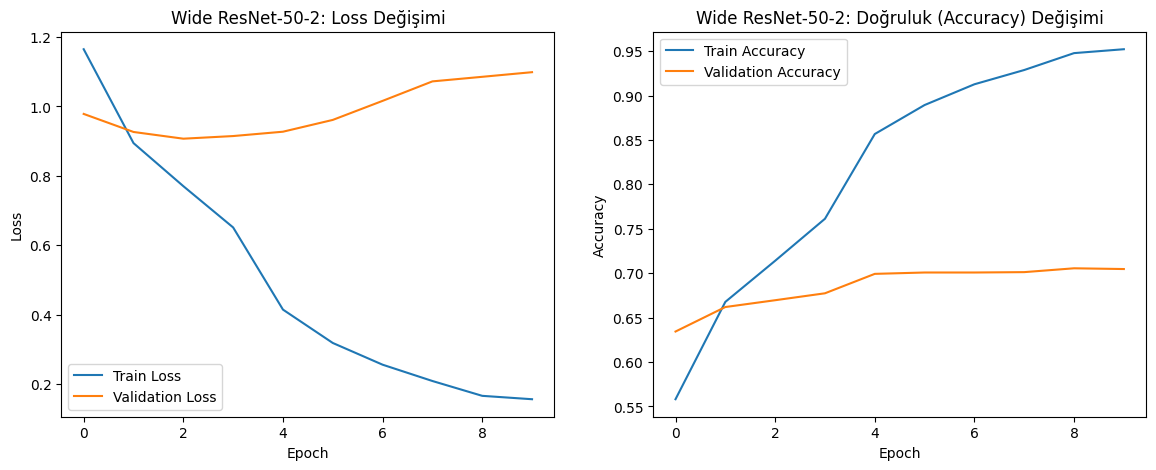

In [ ]:
# BLOK 7: Grafikleri Oluşturma
plt.figure(figsize=(14, 5))


plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Validation Loss')
plt.title('Wide ResNet-50-2: Loss Değişimi')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()


plt.subplot(1, 2, 2)
plt.plot(history['train_acc'], label='Train Accuracy')
plt.plot(history['val_acc'], label='Validation Accuracy')
plt.title('Wide ResNet-50-2: Doğruluk (Accuracy) Değişimi')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.savefig('wide_resnet_grafikler.png') 
plt.show()


🧠 SİSTEM TESTİ SONUCU
📷 Gerçek Etiket: fear
🤖 Tahmin Edilen: sad (Güven: %75.08)

🎬 FİLM ÖNERİSİ
--------------------
Film Adı: The Shawshank Redemption
Puan: 9.3 ⭐
Tür: Drama
Özet: Two imprisoned men bond over a number of years, finding solace and eventual redemption through acts of common decency.


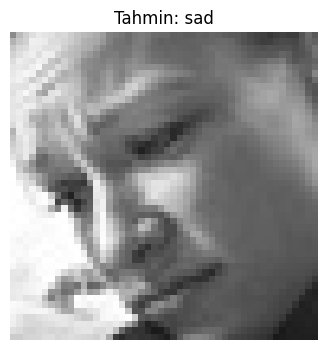

In [ ]:



emotion_genre_mapping = {
    'happy': ['Comedy', 'Musical', 'Animation', 'Family'],
    'sad': ['Drama', 'Romance', 'Biography'],
    'angry': ['Action', 'War', 'Crime', 'Western'],
    'fear': ['Horror', 'Thriller', 'Mystery'],
    'surprise': ['Sci-Fi', 'Fantasy', 'Adventure'],
    'disgust': ['History', 'Horror'],
    'neutral': ['Documentary', 'Biography', 'Drama']
}


def recommend_movie(predicted_emotion, csv_path='imdb_top_1000.csv'):
    emotion_key = predicted_emotion.lower()

    try:
        df = pd.read_csv(csv_path)
        target_genres = emotion_genre_mapping.get(emotion_key, [])

        if not target_genres:
            return "Bu duygu için tür eşleşmesi yapılamadı."

        
        filtered_df = df[df['Genre'].apply(lambda x: any(g in x for g in target_genres))]

        if filtered_df.empty:
            return "Bu türde listede film bulunamadı."

        
        top_movie = filtered_df.sort_values(by='IMDB_Rating', ascending=False).iloc[0]

        return top_movie

    except FileNotFoundError:
        return "Hata: imdb_top_1000.csv dosyası bulunamadı."


def test_system():
    model.eval()

    
    random_class = np.random.choice(class_names)
    class_path = os.path.join(test_dir, random_class)

    if not os.path.exists(class_path) or len(os.listdir(class_path)) == 0:
        print("Test klasörü boş veya bulunamadı.")
        return

    random_image_name = np.random.choice(os.listdir(class_path))
    image_path = os.path.join(class_path, random_image_name)

    
    img = Image.open(image_path).convert('RGB')
    input_tensor = data_transforms['test'](img).unsqueeze(0).to(device)

    
    with torch.no_grad():
        outputs = model(input_tensor)
        probs = torch.nn.functional.softmax(outputs, dim=1)[0]
        confidence, pred_idx = torch.max(probs, 0)

    predicted_label = class_names[pred_idx]

    
    print("\n" + "="*40)
    print(f"🧠 SİSTEM TESTİ SONUCU")
    print("="*40)
    print(f"📷 Gerçek Etiket: {random_class}")
    print(f"🤖 Tahmin Edilen: {predicted_label} (Güven: %{confidence.item()*100:.2f})")

    
    movie = recommend_movie(predicted_label)

    print("\n🎬 FİLM ÖNERİSİ")
    print("-" * 20)
    if isinstance(movie, str):
        print(movie)
    else:
        print(f"Film Adı: {movie['Series_Title']}")
        print(f"Puan: {movie['IMDB_Rating']} ⭐")
        print(f"Tür: {movie['Genre']}")
        print(f"Özet: {movie['Overview']}")

    
    plt.figure(figsize=(4,4))
    plt.imshow(img)
    plt.title(f"Tahmin: {predicted_label}")
    plt.axis('off')
    plt.show()


test_system()

Test seti üzerinde detaylı analiz yapılıyor...


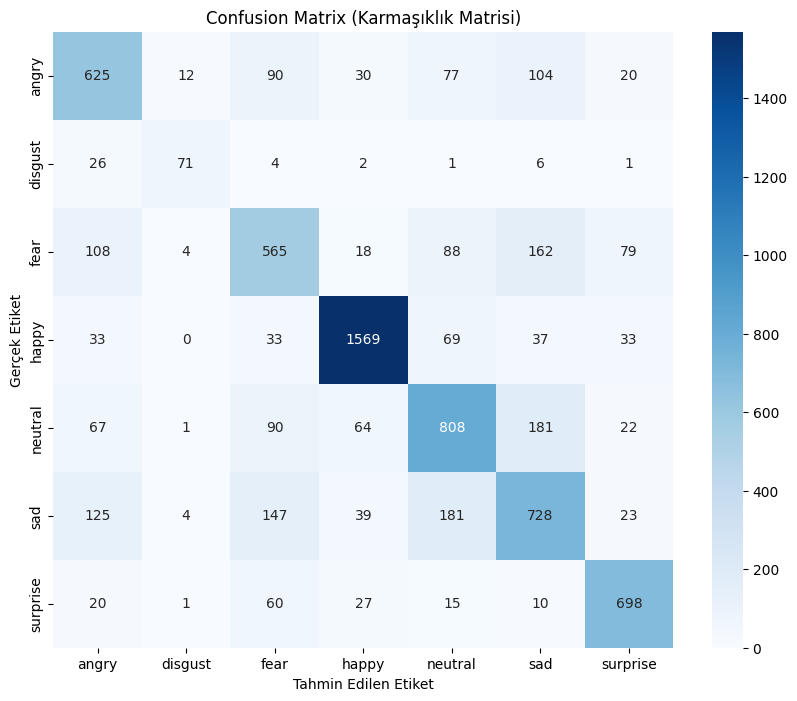


SINIF BAZLI PERFORMANS TABLOSU
              precision    recall  f1-score      support
angry          0.622510  0.652401  0.637105   958.000000
disgust        0.763441  0.639640  0.696078   111.000000
fear           0.571284  0.551758  0.561351  1024.000000
happy          0.897084  0.884442  0.890718  1774.000000
neutral        0.652139  0.655312  0.653722  1233.000000
sad            0.592834  0.583801  0.588283  1247.000000
surprise       0.796804  0.839952  0.817809   831.000000
accuracy       0.705489  0.705489  0.705489     0.705489
macro avg      0.699442  0.686758  0.692152  7178.000000
weighted avg   0.705353  0.705489  0.705182  7178.000000


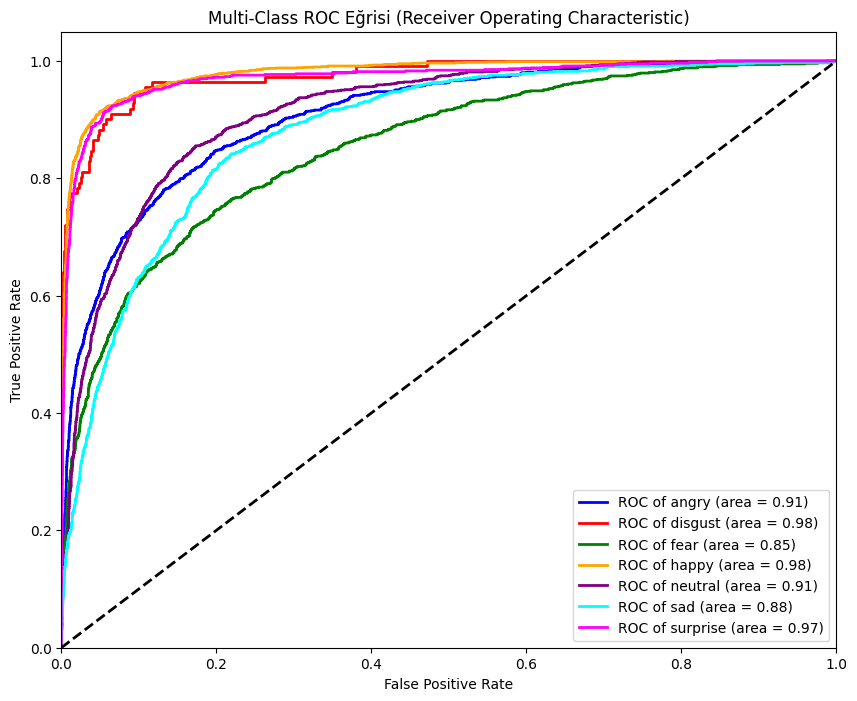

In [9]:
# BLOK 9: Gelişmiş Performans Analizi (Rapor İçin Grafikler ve Tablolar)
# Bu blok hocanın istediği ROC, Confusion Matrix ve Detaylı Tabloyu oluşturur.

from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
from sklearn.preprocessing import label_binarize
import seaborn as sns
import pandas as pd
import numpy as np
from itertools import cycle

def evaluate_model_comprehensive(model, dataloader, class_names):
    model.eval()

    y_true = []
    y_pred = []
    y_score = [] # ROC için olasılık değerleri

    print("Test seti üzerinde detaylı analiz yapılıyor...")

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)

            # Olasılıkları al (Softmax)
            probs = torch.nn.functional.softmax(outputs, dim=1)

            _, preds = torch.max(outputs, 1)

            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())
            y_score.extend(probs.cpu().numpy())

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    y_score = np.array(y_score)

    # 1. Confusion Matrix Çizimi
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title('Confusion Matrix (Karmaşıklık Matrisi)')
    plt.ylabel('Gerçek Etiket')
    plt.xlabel('Tahmin Edilen Etiket')
    plt.savefig('confusion_matrix.png')
    plt.show()

    # 2. Sınıf Bazlı Performans Tablosu (Hocanın İstediği Tablo)
    print("\n" + "="*50)
    print("SINIF BAZLI PERFORMANS TABLOSU")
    print("="*50)

    report = classification_report(y_true, y_pred, target_names=class_names, output_dict=True)
    df_report = pd.DataFrame(report).transpose()

    # Tabloyu görselleştirip kaydetme
    print(df_report)
    df_report.to_csv('sinif_bazli_performans.csv') # CSV olarak kaydeder

    # 3. ROC Eğrisi ve AUC Hesaplaması (Multi-class)
    # Etiketleri binarize et (One-vs-Rest mantığı için)
    y_true_bin = label_binarize(y_true, classes=range(len(class_names)))
    n_classes = len(class_names)

    fpr = dict()
    tpr = dict()
    roc_auc = dict()

    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_score[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    # ROC Grafiği Çizimi
    plt.figure(figsize=(10, 8))
    colors = cycle(['blue', 'red', 'green', 'orange', 'purple', 'cyan', 'magenta'])

    for i, color in zip(range(n_classes), colors):
        plt.plot(fpr[i], tpr[i], color=color, lw=2,
                 label='ROC of {0} (area = {1:0.2f})'.format(class_names[i], roc_auc[i]))

    plt.plot([0, 1], [0, 1], 'k--', lw=2)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Multi-Class ROC Eğrisi (Receiver Operating Characteristic)')
    plt.legend(loc="lower right")
    plt.savefig('roc_curve.png')
    plt.show()

# Fonksiyonu Çalıştır
evaluate_model_comprehensive(model, dataloaders['test'], class_names)